In [45]:
import pickle as pkl
import seaborn as sns
from matplotlib import pyplot as plt
from communication_subspace.core.reducedRankcrossval import select_optimal_dimension
import numpy as np
from collections import defaultdict

In [2]:
with open("../data/f7d46a15-9498-40dc-90da-fb977ce844be_rrr_fa_results_stim.pkl", "rb") as f:
    animal_subspace = pkl.load(f)

In [5]:
frames = animal_subspace.keys()

In [6]:
region_wise_data = animal_subspace[2]

In [64]:
def plot_communication_subspace(region_wise_data, frame_idx):
    rrr_dict_dims = {}
    rrr_dict_err = {}
    regions = set()
    for region_pairs in region_wise_data["rrr"].keys():
        region_a = region_pairs.rsplit("_")[0].lstrip("['").rstrip("]'")
        region_b = region_pairs.rsplit("_")[1].lstrip("['").rstrip("]'")
        dims, _, err = select_optimal_dimension(
            region_wise_data["rrr"][region_pairs]["cv_results"]
        )
        rx = region_a + "_" + region_b
        rrr_dict_dims[rx] = dims
        rrr_dict_err[rx] = err
        regions.add(region_a)
        regions.add(region_b)
    data_array = np.zeros((len(list(regions)), len(list(regions))))
    regions = sorted(regions)  # ensure ordering
    region_to_idx = {r: i for i, r in enumerate(regions)}
    for pair, value in rrr_dict_dims.items():
        a, b = pair.split("_")
        i = region_to_idx[a]
        j = region_to_idx[b]
        data_array[i, j] = rrr_dict_dims[pair]
    data_array_err = np.zeros((len(list(regions)), len(list(regions))))
    regions = sorted(regions)  # ensure ordering
    region_to_idx = {r: i for i, r in enumerate(regions)}
    for pair, value in rrr_dict_dims.items():
        a, b = pair.split("_")
        i = region_to_idx[a]
        j = region_to_idx[b]
        data_array_err[i, j] = rrr_dict_err[pair]
    fig, ax = plt.subplots(figsize=(10, 4), ncols=2)
    sns.heatmap(data_array, cmap="viridis", xticklabels=regions, yticklabels=regions, ax=ax[0])
    sns.heatmap(data_array_err, cmap="viridis", xticklabels=regions, yticklabels=regions, ax=ax[1])
    plt.suptitle(f"{frame_idx}")
    return data_array

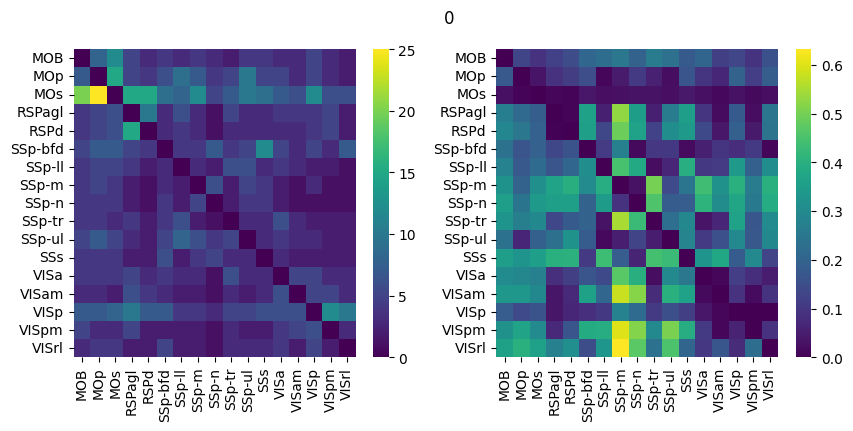

In [65]:
zeroth = plot_communication_subspace(animal_subspace[0], 0)

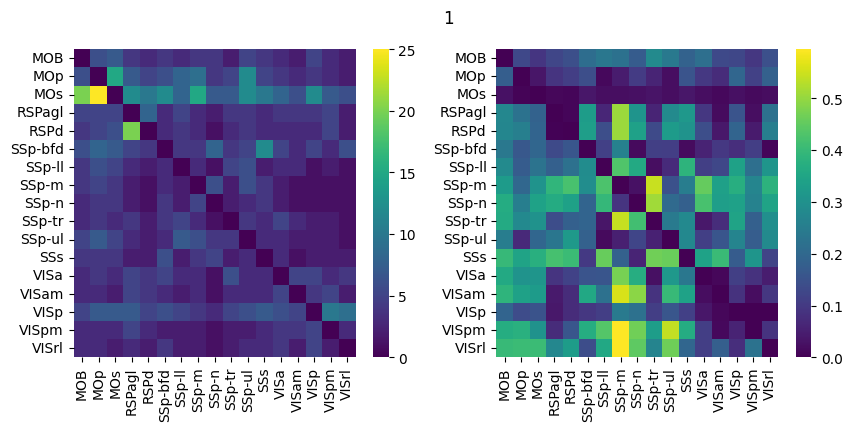

In [66]:
first = plot_communication_subspace(animal_subspace[1], 1)

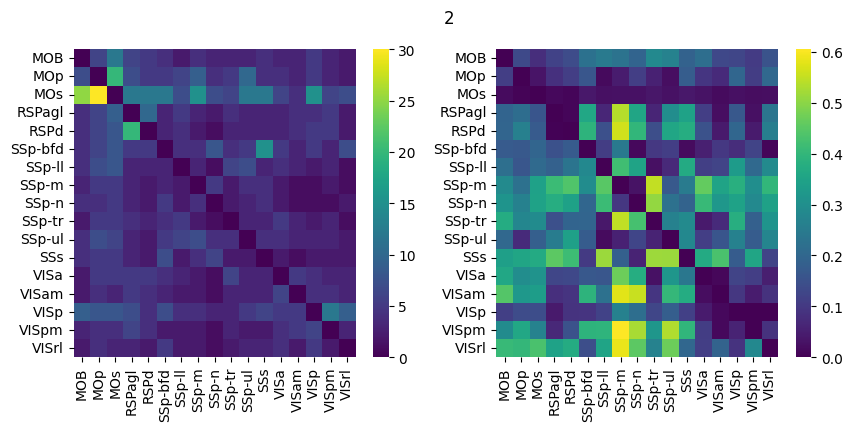

In [67]:
second = plot_communication_subspace(animal_subspace[2], 2)

In [71]:
from scipy.stats import spearmanr, kendalltau

In [ ]:
region_counts = {}
for idx in range(len(data_epoch)):
    region_counts[used_regions[idx][0]] = data_epoch[idx].shape[1]
regions = sorted(regions)  # ensure ordering
region_to_idx = {r: i for i, r in enumerate(regions)}
counts = np.zeros((len(region_counts.keys())))
for r in region_counts.keys():
    counts[region_to_idx[r]] = region_counts[r]

In [88]:
counts

array([ 78.,  92., 173.,  45.,  64.,  71.,  27.,  34.,  19.,  20.,  38.,
        33.,  23.,  16., 121.,  20.,  17.])

In [89]:
min_voxel_count = np.zeros((len(counts), len(counts)))

for idx in range(len(counts)):
    for idy in range(len(counts)):
        if idx == idy:
            continue
        else:
            min_voxel_count[idx, idy] = min(counts[idx], counts[idy])

In [106]:
def network_mantel_test(matrix_a, matrix_b, permutations=10000):
    """
    Performs a Mantel test to correlate two NxN network matrices.
    Uses Spearman correlation and ignores the diagonal (self-connections).
    """
    N = matrix_a.shape[0]

    # 1. Extract off-diagonal elements (ignore self-connections)
    mask = ~np.eye(N, dtype=bool)
    a_flat = matrix_a[mask]
    b_flat = matrix_b[mask]

    # 2. Calculate true observed correlation
    obs_corr, _ = spearmanr(a_flat, b_flat)

    # 3. Permutation Test
    null_correlations = np.zeros(permutations)

    for i in range(permutations):
        # Shuffle the NODES (regions), not the edges
        # This preserves the network dependency structure
        idx = np.random.permutation(N)

        # Shuffle matrix_a symmetrically (rows and columns)
        shuffled_a = matrix_a[idx, :][:, idx]

        # Correlate shuffled_a with the original matrix_b
        null_corr, _ = spearmanr(shuffled_a[mask], b_flat)
        null_correlations[i] = null_corr

    # 4. Calculate empirical p-value
    # How many times did random network shuffling produce a correlation
    # as strong or stronger than what we observed?
    p_value = np.sum(np.abs(null_correlations) >= np.abs(obs_corr)) / permutations

    print(f"Mantel Test (Spearman): r = {obs_corr:.4f}, p = {p_value:.4f}")

    return obs_corr, p_value


def compute_and_plot_ratio_matrix(capacity_matrix, rrr_matrix, region_names=None):
    """
    Converts raw RRR dimensions to a Capacity Ratio Matrix and plots the comparison.
    """
    N = len(capacity_matrix)

    ratio_matrix = np.zeros_like(rrr_matrix, dtype=float)
    np.divide(rrr_matrix, capacity_matrix, out=ratio_matrix, where=capacity_matrix > 0)

    np.fill_diagonal(rrr_matrix, np.nan)
    np.fill_diagonal(ratio_matrix, np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    im1 = axes[0].imshow(rrr_matrix, cmap="viridis", aspect="auto")
    axes[0].set_title("Raw Topology: RRR Dimensions)")
    axes[0].set_xlabel("Target Region")
    axes[0].set_ylabel("Source Region")
    fig.colorbar(im1, ax=axes[0], label="Rank (k)")

    im2 = axes[1].imshow(ratio_matrix, cmap="viridis", aspect="auto", vmin=0, vmax=1)
    axes[1].set_title("Normalized Topology: Communication Ratio")
    axes[1].set_xlabel("Target Region")
    axes[1].set_ylabel("Source Region")
    fig.colorbar(im2, ax=axes[1], label="Ratio (Used / Capacity)")

    # Add ticks if region names are provided
    if region_names is not None:
        for ax in axes:
            ax.set_xticks(np.arange(N))
            ax.set_yticks(np.arange(N))
            ax.set_xticklabels(region_names, rotation=45, ha="right")
            ax.set_yticklabels(region_names)

    plt.tight_layout()
    plt.show()

In [94]:
r, p = network_mantel_test(zeroth, min_voxel_count)

Mantel Test (Spearman): r = 0.4513, p = 0.0011


In [95]:
r, p = network_mantel_test(first, min_voxel_count)

Mantel Test (Spearman): r = 0.4648, p = 0.0007


In [96]:
r, p = network_mantel_test(second, min_voxel_count)

Mantel Test (Spearman): r = 0.4650, p = 0.0018


Text(0.5, 1.0, 'Voxel counts')

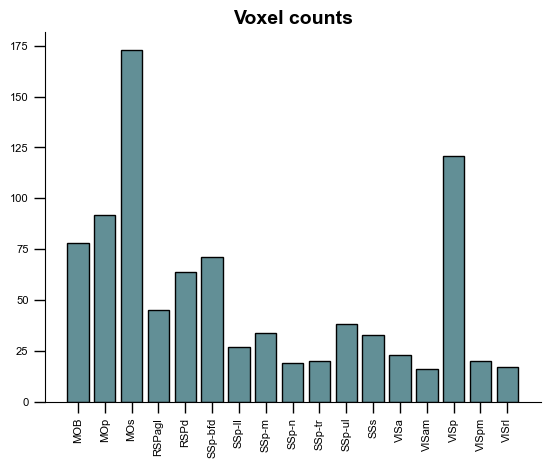

In [119]:
plt.bar(np.arange(len(counts)), counts, color="#044c579f", edgecolor="k")
plt.xticks(np.arange(len(counts)), regions, rotation=90)
plt.title("Voxel counts")

<Axes: >

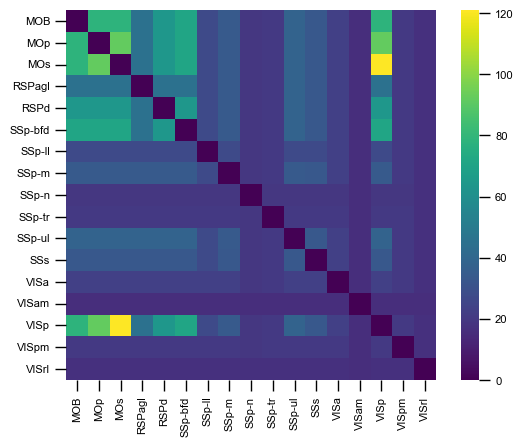

In [102]:
sns.heatmap(min_voxel_count, cmap="viridis", square=True, xticklabels=regions, yticklabels=regions)